<a href="https://colab.research.google.com/github/A1maan/Dyslexia_DeepLSE/blob/main/Dyslexia_DL_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install livelossplot --quiet
!pip install mrmr_selection --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from livelossplot import PlotLosses
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, auc
import mrmr
import kagglehub

In [ ]:
# Code to update kagglehub (uncomment if needed)
#!pip install --upgrade kagglehub

#**Data Preprocessing**

In [ ]:
print(path)

/root/.cache/kagglehub/datasets/luzrello/dyslexia/versions/1


In [ ]:
path = kagglehub.dataset_download("luzrello/dyslexia")

df_desktop = pd.read_csv(path + "/Dyt-desktop.csv", delimiter=';')
df_desktop

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,No
4,Female,No,Yes,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,Male,No,No,10,7,7,0,7,1.0,0.0,...,2,0.670000,0.33,4,1,3,1,0.250000,0.750000,Yes
3640,Female,No,Yes,15,9,9,0,9,1.0,0.0,...,3,0.750000,0.25,4,2,2,2,0.500000,0.500000,No
3641,Female,No,Yes,15,11,11,0,11,1.0,0.0,...,3,0.600000,0.40,4,2,2,2,0.500000,0.500000,No
3642,Female,No,Yes,15,10,10,0,10,1.0,0.0,...,3,0.750000,0.25,4,3,1,3,0.750000,0.250000,No


In [ ]:
df_tablet = pd.read_csv(path + "/Dyt-tablet.csv", delimiter=';')
df_tablet

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,Yes,No,7,6,6,0,6,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
1,Female,Yes,No,7,7,7,0,7,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
2,Female,Yes,No,7,6,6,0,6,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3,Male,Yes,No,7,5,5,0,5,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
4,Male,Yes,No,7,8,6,2,8,0.75,0.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1390,Male,Yes,No,17,13,13,0,13,1.00,0.00,...,35.0,0.114286,0.0,26.0,4.0,0.0,26.0,0.153846,0.000000,No
1391,Female,Yes,Yes,17,9,9,0,9,1.00,0.00,...,35.0,0.114286,0.0,26.0,4.0,0.0,26.0,0.153846,0.000000,No
1392,Male,Yes,Yes,17,10,10,0,10,1.00,0.00,...,35.0,0.114286,0.0,27.0,3.0,2.0,27.0,0.111111,0.074074,No
1393,Female,Yes,Yes,17,11,11,0,11,1.00,0.00,...,35.0,0.114286,0.0,26.0,4.0,0.0,26.0,0.153846,0.000000,No


In [ ]:
print(df_desktop.info())
print()
print(df_tablet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Columns: 197 entries, Gender to Dyslexia
dtypes: float64(64), int64(129), object(4)
memory usage: 5.5+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Columns: 197 entries, Gender to Dyslexia
dtypes: float64(128), int64(65), object(4)
memory usage: 2.1+ MB
None


In [ ]:
print(df_desktop.select_dtypes(include=['number']).describe())
print(df_desktop.select_dtypes(include=['object']).describe())
print()
print("=" * 100)
print()
print(df_tablet.select_dtypes(include=['number']).describe())
print(df_tablet.select_dtypes(include=['object']).describe())

               Age      Clicks1        Hits1      Misses1       Score1  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000   
mean     10.484907     6.104281     3.683315     0.794731     3.748079   
std       2.478132     4.473068     4.194311     1.191338     4.172533   
min       7.000000     0.000000     0.000000     0.000000     0.000000   
25%       8.750000     3.000000     0.000000     0.000000     0.000000   
50%      10.000000     5.000000     1.000000     0.000000     1.000000   
75%      12.000000     8.000000     7.000000     1.000000     7.000000   
max      17.000000    84.000000    19.000000    18.000000    19.000000   

         Accuracy1    Missrate1      Clicks2        Hits2      Misses2  ...  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000  ...   
mean      3.047372     4.541253     9.547475     4.844951     0.888310  ...   
std      35.446814    40.329119     5.462742     3.699285     1.829512  ...   
min       0.00000

In [ ]:
# Missing values
print(df_desktop.isnull().sum())
print()
print("=" * 100)
print()
print(df_tablet.isnull().sum())

Gender        0
Nativelang    0
Otherlang     0
Age           0
Clicks1       0
             ..
Misses32      0
Score32       0
Accuracy32    0
Missrate32    0
Dyslexia      0
Length: 197, dtype: int64


Gender          0
Nativelang      0
Otherlang       0
Age             0
Clicks1         0
             ... 
Misses32      897
Score32       897
Accuracy32    896
Missrate32    896
Dyslexia        0
Length: 197, dtype: int64


In [ ]:
# Check the percentage of missing values for each column
missing_percentages = df_desktop.isnull().mean() * 100

# Filter columns with missing values
missing_percentages = missing_percentages[missing_percentages > 0]

# Sort the results in descending order
missing_percentages = missing_percentages.sort_values(ascending=False)

pd.set_option('display.max_rows', None)
# Display the percentages
print(missing_percentages)

pd.reset_option('display.max_rows')

Series([], dtype: float64)


Desktop Target Distribution:
Dyslexia
No     89.242591
Yes    10.757409
Name: proportion, dtype: float64


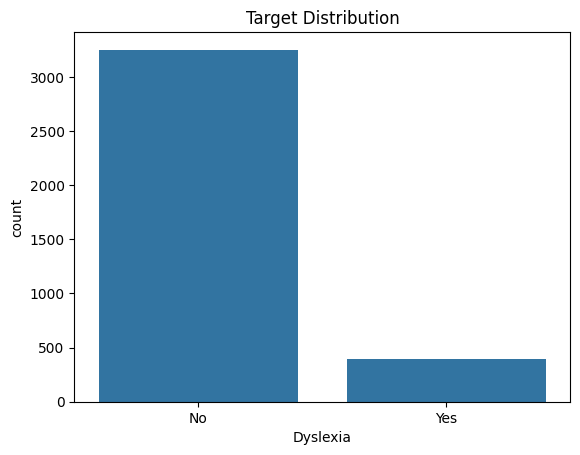


Tablet Target Distribution:
Dyslexia
No     89.390681
Yes    10.609319
Name: proportion, dtype: float64


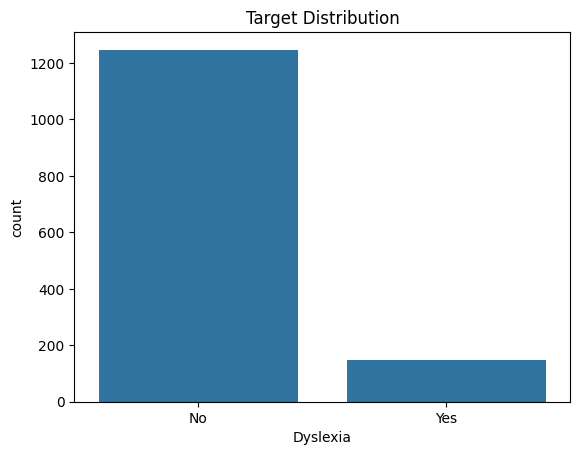

In [ ]:
# Checking output label imbalance
target_column = "Dyslexia"

print("Desktop Target Distribution:")
print(f"{df_desktop[target_column].value_counts(normalize=True) * 100}")
sns.countplot(x=df_desktop[target_column])
plt.title("Target Distribution")
plt.show()
print()
print("Tablet Target Distribution:")
print(f"{df_tablet[target_column].value_counts(normalize=True) * 100}")
sns.countplot(x=df_tablet[target_column])
plt.title("Target Distribution")
plt.show()

Clearly, there is a huge imbalance in the positive and negative classes.

Stratified KFold to be used.

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df_desktop.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    print(f"Encoding column: {col}")
    le = LabelEncoder()
    df_desktop[col] = le.fit_transform(df_desktop[col])
df_desktop

Encoding column: Gender
Encoding column: Nativelang
Encoding column: Otherlang
Encoding column: Dyslexia


,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,1,0,1,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,0
1,0,1,1,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,1
2,0,0,1,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,0
3,0,0,1,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,0
4,0,0,1,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,1,0,0,10,7,7,0,7,1.0,0.0,...,2,0.670000,0.33,4,1,3,1,0.250000,0.750000,1
3640,0,0,1,15,9,9,0,9,1.0,0.0,...,3,0.750000,0.25,4,2,2,2,0.500000,0.500000,0
3641,0,0,1,15,11,11,0,11,1.0,0.0,...,3,0.600000,0.40,4,2,2,2,0.500000,0.500000,0
3642,0,0,1,15,10,10,0,10,1.0,0.0,...,3,0.750000,0.25,4,3,1,3,0.750000,0.250000,0


In [ ]:
print("Desktop Target Distribution:")
print(f"{df_desktop[target_column].value_counts(normalize=True) * 100}")

Desktop Target Distribution:
Dyslexia
0    89.242591
1    10.757409
Name: proportion, dtype: float64


In [ ]:
duplicates = df_desktop.duplicated().sum()
print(f"Number of Duplicate Samples: {duplicates}")
if duplicates > 0:
    print("Dropping Duplicates...")
    df_desktop.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
else:
    print("No Duplicate Samples Found.")

Number of Duplicate Samples: 0
No Duplicate Samples Found.


In [ ]:
X = df_desktop.drop('Dyslexia', axis=1)
y = df_desktop['Dyslexia']
input_size = X.shape[1]

In [ ]:
my_state = 42
torch.manual_seed(my_state)
np.random.seed(my_state)
torch.cuda.manual_seed_all(my_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# **DNN Implementation**

In [ ]:
class DNN(nn.Module):
  def __init__(self, input_size):
    super(DNN, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.network(x)

In [ ]:
def reset_weights(m):
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

In [ ]:
num_epochs = 35
learning_rate = 1e-3
criterion = nn.BCELoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

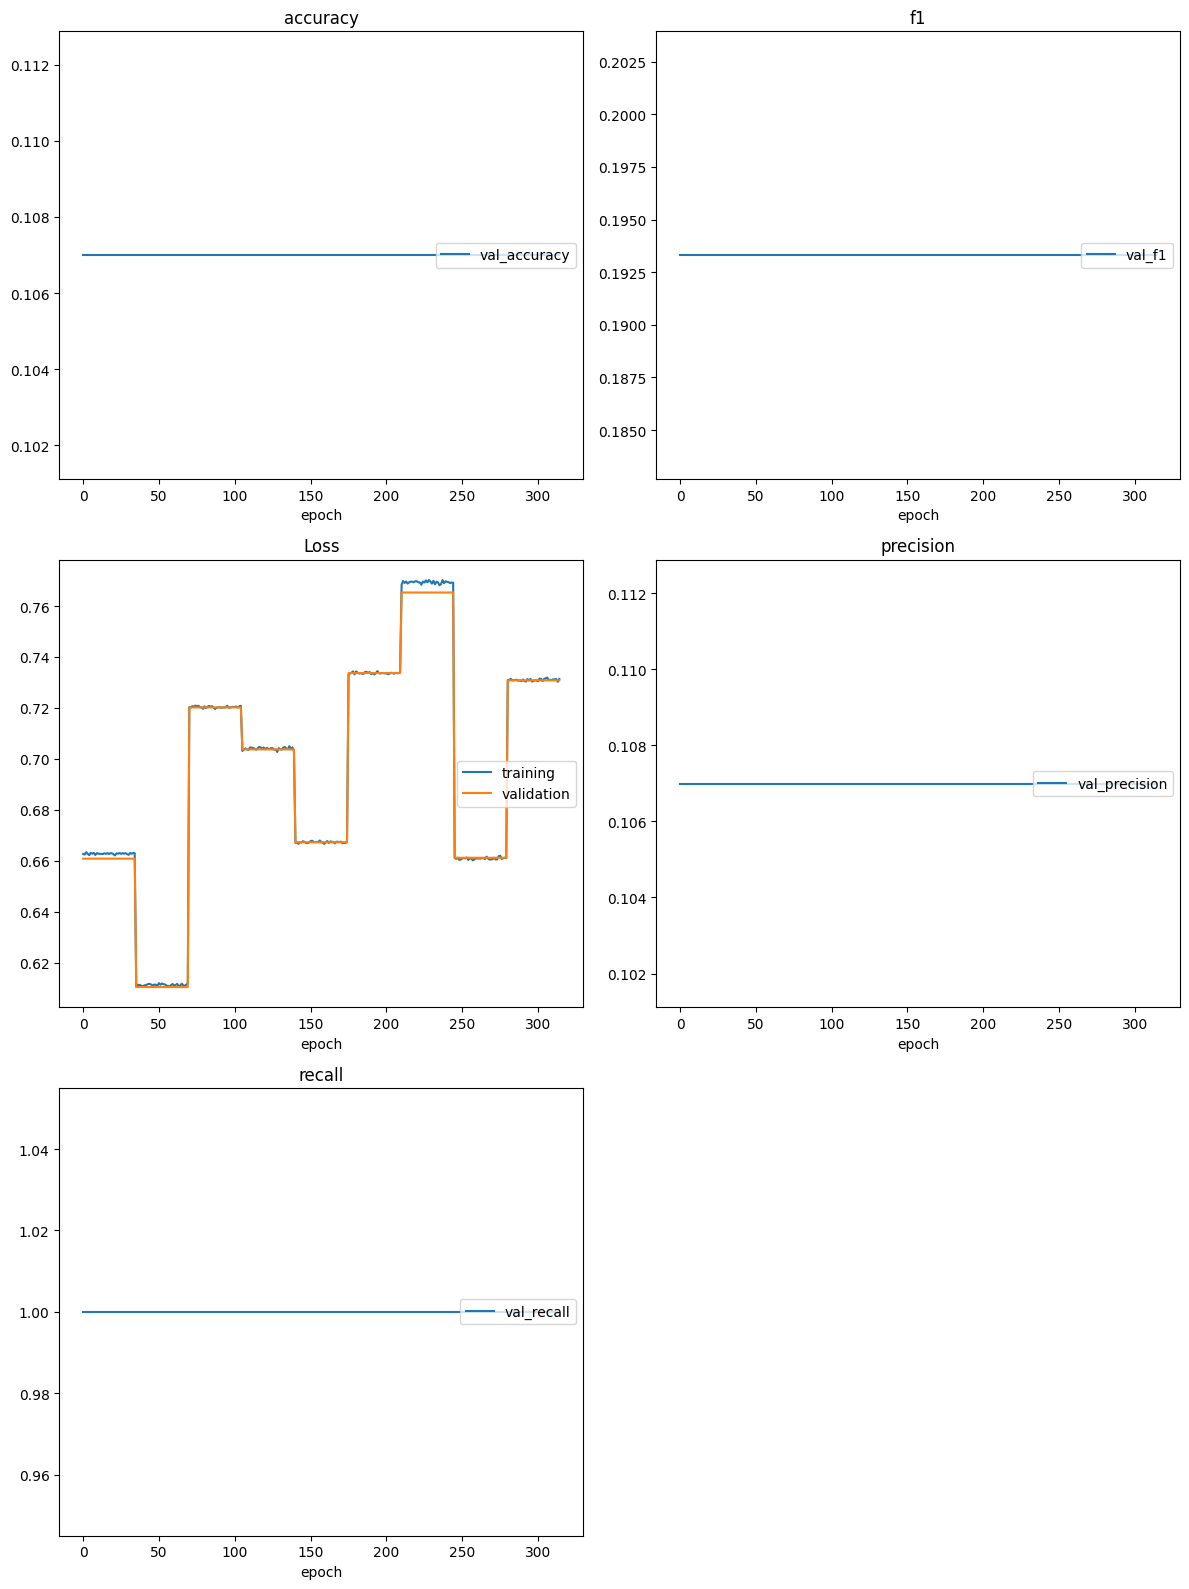

accuracy
	val_accuracy     	 (min:    0.107, max:    0.107, cur:    0.107)
f1
	val_f1           	 (min:    0.193, max:    0.193, cur:    0.193)
Loss
	training         	 (min:    0.611, max:    0.770, cur:    0.731)
	validation       	 (min:    0.610, max:    0.765, cur:    0.731)
precision
	val_precision    	 (min:    0.107, max:    0.107, cur:    0.107)
recall
	val_recall       	 (min:    1.000, max:    1.000, cur:    1.000)
Epoch 35/35, Train Loss: 0.7314, Val Loss: 0.7308, Accuracy: 0.1070, Precision: 0.1070, Recall: 1.0000, F1 Score: 0.1933


In [ ]:
from mrmr import mrmr_classif

liveloss = PlotLosses()
K = list(range(10,55,5))

k_f1 = []

for k in K:
  print(f"K = {k}")

  selected_features = mrmr_classif(X, y, K=k)
  X_selected = X.loc[:, selected_features]

  X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=my_state, stratify=y)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

  y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
  y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1).to(device)

  input_size = X_selected.shape[1]

  model = DNN(input_size).to(device)
  model.apply(reset_weights)

  for epoch in range(num_epochs):
    logs = {}

    # Training mode
    model.train()

    outputs = model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Validation mode
    model.eval()
    with torch.no_grad():
      val_outputs = model(X_test_tensor)

      val_loss = criterion(val_outputs, y_test_tensor)
      val_preds = (val_outputs >= 0.24).float()

      y_test = y_test_tensor.cpu().numpy()
      val_preds = val_preds.cpu().numpy()

      # Metrics
      val_accuracy = accuracy_score(y_test, val_preds)
      val_precision = precision_score(y_test, val_preds)
      val_recall = recall_score(y_test, val_preds)
      val_f1 = f1_score(y_test, val_preds)


    logs["loss"] = train_loss.item()
    logs["val_loss"] = val_loss.item()
    logs["val_accuracy"] = val_accuracy
    logs["val_precision"] = val_precision
    logs["val_recall"] = val_recall
    logs["val_f1"] = val_f1

    liveloss.update(logs)
    liveloss.send()

    tqdm.write(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
        f"Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, "
        f"Recall: {val_recall:.4f}, F1 Score: {val_f1:.4f}"
    )
  k_f1.append(val_f1)

Text(0.5, 1.0, 'F1-score vs. K')

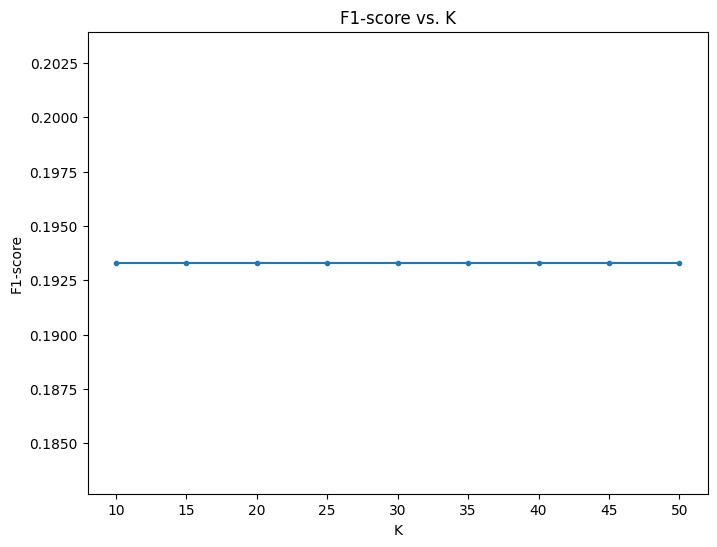

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(K, k_f1, marker='.', label='F1-score')
plt.xlabel('K')
plt.ylabel('F1-score')
plt.title('F1-score vs. K')

In [ ]:
model.eval()

y_true = []
y_scores = []

with torch.no_grad():
  outputs = model(X_test_tensor)

  y_true.extend(y_test_tensor.cpu().numpy())
  y_scores.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

Optimal Threshold: 0.2328
Best Precision: 0.5532, Best Recall: 0.3333, Best F1-Score: 0.4160


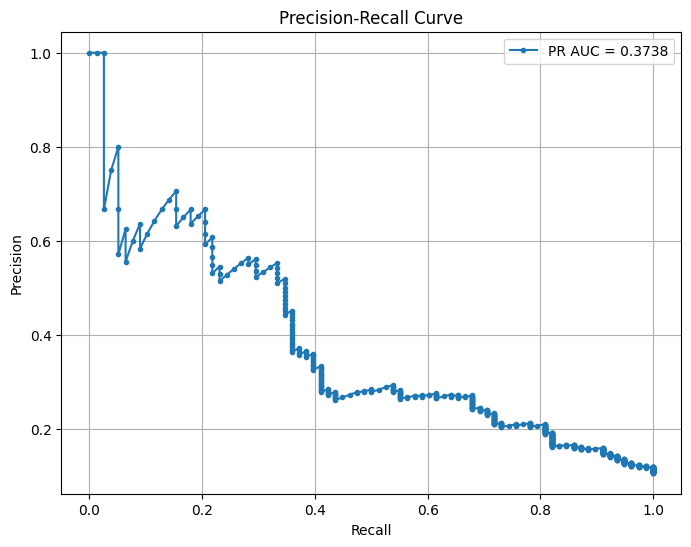

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Best Precision: {precision[optimal_idx]:.4f}, Best Recall: {recall[optimal_idx]:.4f}, Best F1-Score: {f1_scores[optimal_idx]:.4f}")

pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

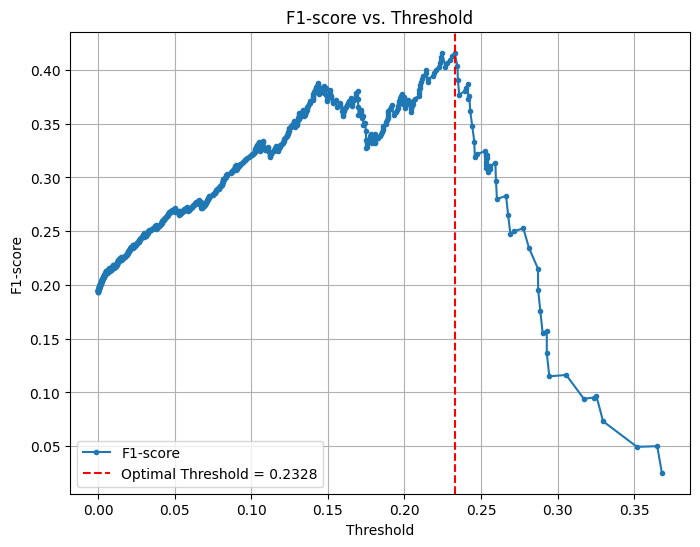

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores[:-1], marker='.', label='F1-score')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

## **Using ADASYN (without mRMR)**

In [ ]:
from imblearn.over_sampling import ADASYN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=my_state, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

adasyn = ADASYN(sampling_strategy='auto', random_state=my_state)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

X_train_resampled_tensor = torch.tensor(X_train_resampled, dtype=torch.float32).to(device)
y_train_resampled_tensor = torch.tensor(y_train_resampled.values, dtype=torch.float32).view(-1, 1).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1).to(device)

In [ ]:
num_epochs = 35
learning_rate = 1e-3
criterion = nn.BCELoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DNN(input_size).to(device)
model.apply(reset_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

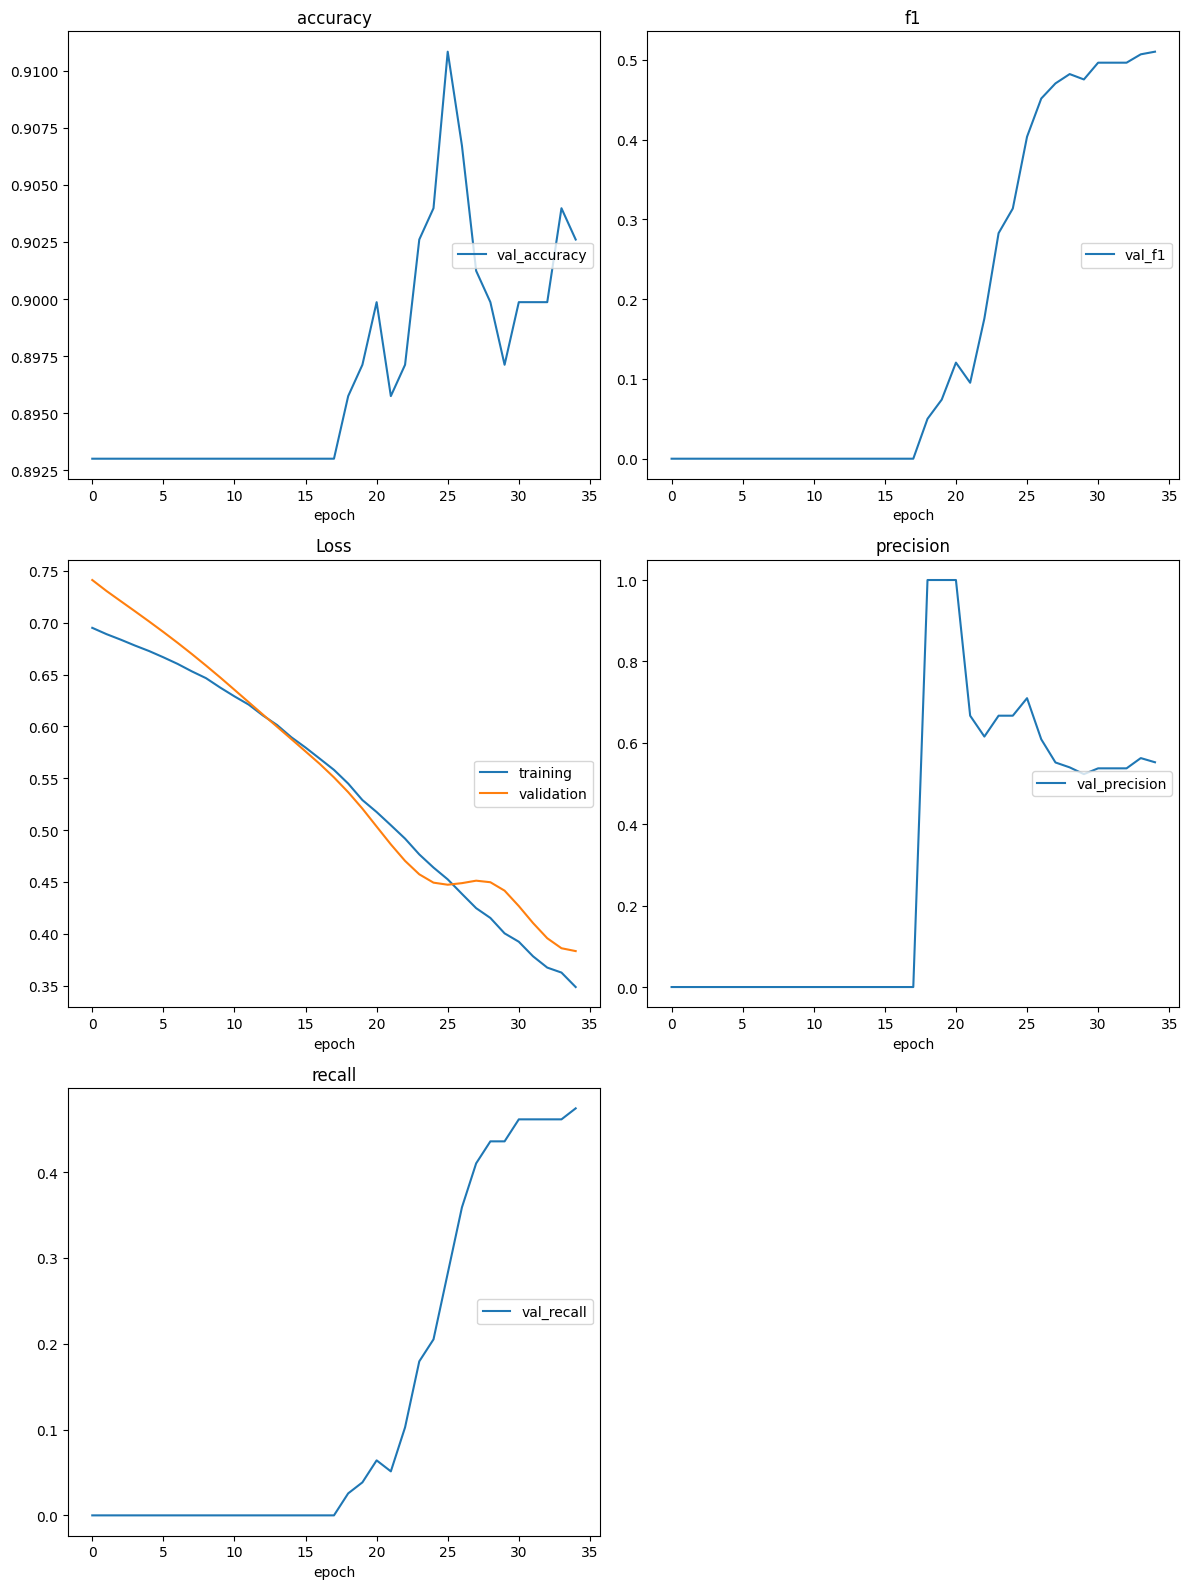

accuracy
	val_accuracy     	 (min:    0.893, max:    0.911, cur:    0.903)
f1
	val_f1           	 (min:    0.000, max:    0.510, cur:    0.510)
Loss
	training         	 (min:    0.349, max:    0.695, cur:    0.349)
	validation       	 (min:    0.383, max:    0.741, cur:    0.383)
precision
	val_precision    	 (min:    0.000, max:    1.000, cur:    0.552)
recall
	val_recall       	 (min:    0.000, max:    0.474, cur:    0.474)
Epoch 35/35, Train Loss: 0.3485, Val Loss: 0.3832, Accuracy: 0.9026, Precision: 0.5522, Recall: 0.4744, F1 Score: 0.5103


In [ ]:
liveloss = PlotLosses()

for epoch in range(num_epochs):
  logs = {}

  # Training mode
  model.train()

  outputs = model(X_train_resampled_tensor)
  train_loss = criterion(outputs, y_train_resampled_tensor)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  # Validation mode
  model.eval()
  with torch.no_grad():
    val_outputs = model(X_test_tensor)

    val_loss = criterion(val_outputs, y_test_tensor)
    val_preds = (val_outputs >= 0.8).float()

    y_test = y_test_tensor.cpu().numpy()
    val_preds = val_preds.cpu().numpy()

    # Metrics
    val_accuracy = accuracy_score(y_test, val_preds)
    val_precision = precision_score(y_test, val_preds)
    val_recall = recall_score(y_test, val_preds)
    val_f1 = f1_score(y_test, val_preds)


  logs["loss"] = train_loss.item()
  logs["val_loss"] = val_loss.item()
  logs["val_accuracy"] = val_accuracy
  logs["val_precision"] = val_precision
  logs["val_recall"] = val_recall
  logs["val_f1"] = val_f1

  liveloss.update(logs)
  liveloss.send()

  tqdm.write(
      f"Epoch {epoch + 1}/{num_epochs}, "
      f"Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
      f"Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, "
      f"Recall: {val_recall:.4f}, F1 Score: {val_f1:.4f}"
  )

In [ ]:
model.eval()

y_true = []
y_scores = []

with torch.no_grad():
  outputs = model(X_test_tensor)

  y_true.extend(y_test_tensor.cpu().numpy())
  y_scores.extend(outputs.cpu().numpy())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

Optimal Threshold: 0.7333
Best Precision: 0.5059, Best Recall: 0.5513, Best F1-Score: 0.5276


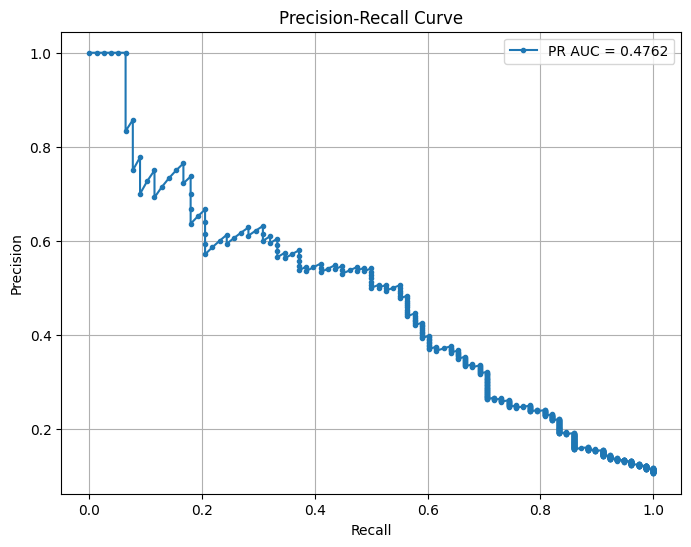

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Best Precision: {precision[optimal_idx]:.4f}, Best Recall: {recall[optimal_idx]:.4f}, Best F1-Score: {f1_scores[optimal_idx]:.4f}")

pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

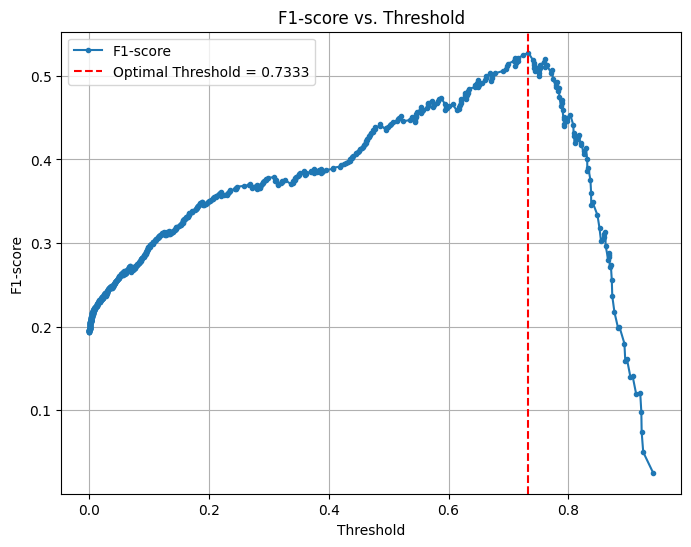

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores[:-1], marker='.', label='F1-score')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# input_size = X.shape[1]
# criterion = nn.BCELoss()
# num_epochs = 50

# skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=my_state)

# # To store metrics for all folds
# fold_metrics = []

# for fold, (train_idx, val_idx) in enumerate(skfold.split(X, y)):
#     print(f"Fold {fold + 1}")
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     # Scale the data
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_val = scaler.transform(X_val)

#     # Convert to tensors
#     X_train = torch.tensor(X_train, dtype=torch.float32)
#     y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
#     X_val = torch.tensor(X_val, dtype=torch.float32)
#     y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

#     # Initialize model and optimizer
#     model = DNN(input_size)
#     model.apply(reset_weights)
#     optimizer = optim.Adam(model.parameters(), lr=1e-3)

#     for epoch in range(num_epochs):
#         # Training phase
#         model.train()
#         outputs = model(X_train)
#         loss = criterion(outputs, y_train)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         # Validation phase
#         model.eval()
#         with torch.no_grad():
#             val_outputs = model(X_val)
#             val_loss = criterion(val_outputs, y_val)

#             # Calculate metrics
#             train_preds = (outputs >= 0.24).float()
#             val_preds = (val_outputs >= 0.24).float()

#             train_accuracy = accuracy_score(y_train.numpy(), train_preds.numpy())
#             val_accuracy = accuracy_score(y_val.numpy(), val_preds.numpy())
#             val_precision = precision_score(y_val.numpy(), val_preds.numpy())
#             val_recall = recall_score(y_val.numpy(), val_preds.numpy())
#             val_f1 = f1_score(y_val.numpy(), val_preds.numpy())

#         print(
#             f"Epoch {epoch + 1}/{num_epochs} | "
#             f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | "
#             f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | "
#             f"Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f} | Val F1: {val_f1:.4f}"
#         )

#     # Compute final metrics for the fold
#     final_val_preds = (val_outputs >= 0.24).float()
#     fold_accuracy = accuracy_score(y_val.numpy(), final_val_preds.numpy())
#     fold_precision = precision_score(y_val.numpy(), final_val_preds.numpy())
#     fold_recall = recall_score(y_val.numpy(), final_val_preds.numpy())
#     fold_f1 = f1_score(y_val.numpy(), final_val_preds.numpy())
#     fold_cm = confusion_matrix(y_val.numpy(), final_val_preds.numpy())

#     # Store metrics for this fold
#     fold_metrics.append({
#         "accuracy": fold_accuracy,
#         "precision": fold_precision,
#         "recall": fold_recall,
#         "f1": fold_f1,
#         "confusion_matrix": fold_cm
#     })

#     print(f"Fold {fold + 1} Confusion Matrix:\n{fold_cm}")
#     print("=" * 100)

In [ ]:
# Compute overall metrics across folds
avg_accuracy = sum([m["accuracy"] for m in fold_metrics]) / len(fold_metrics)
avg_precision = sum([m["precision"] for m in fold_metrics]) / len(fold_metrics)
avg_recall = sum([m["recall"] for m in fold_metrics]) / len(fold_metrics)
avg_f1 = sum([m["f1"] for m in fold_metrics]) / len(fold_metrics)

print(f"Overall Metrics across {skfold.n_splits} folds:")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"F1-Score: {avg_f1:.4f}")

# **DeepLSE Implementation**

In [ ]:
class DeepLSE(nn.Module):
    def __init__(self, input_shape, LV=5):
        super(DeepLSE, self).__init__()

        # Encoder Network
        self.enc_l1 = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3)
        )

        self.enc_l2 = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3)
        )

        self.enc_l3 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3)
        )

        self.encoder_output = nn.Sequential(
              nn.Linear(32, LV),
              nn.Sigmoid()
        )

        # Classifier Network
        self.class_l1 = nn.Sequential(
            nn.Linear(LV, 64),
            nn.ReLU()
        )

        self.class_l2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.class_output = nn.Sequential(
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        # Decoder Network
        self.dec_l1 = nn.Sequential(
            nn.Linear(LV, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3)
        )

        self.dec_l2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3)
        )

        self.dec_l3 = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3)
        )

        self.decoder_output = nn.Linear(128, input_shape)


    def forward(self, x):
        # Encoder
        enc_l1_out = self.enc_l1(x)
        enc_l2_out = self.enc_l2(enc_l1_out)
        enc_l3_out = self.enc_l3(enc_l2_out)
        encoder_out = self.encoder_output(enc_l3_out)

        # Classifier
        class_l1_out = self.class_l1(encoder_out)
        class_l2_out = self.class_l2(class_l1_out)
        class_out = self.class_output(class_l2_out)

        # Decoder
        dec_l1_out = self.dec_l1(encoder_out)
        dec_l2_out = self.dec_l2(dec_l1_out)
        dec_l3_out = self.dec_l3(dec_l2_out)
        decoder_out = self.decoder_output(dec_l3_out)

        return class_out, decoder_out

In [ ]:
from tqdm import tqdm
import itertools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

param_grid = {
    "lambd": [lambd / 10 for lambd in range(1, 11)],  # Loss weightage coefficient
    "latent_var": [lv for lv in range(10, 65, 5)],  # Latent variable size
}

num_epochs = 100
learning_rate = 1e-3

param_combinations = list(itertools.product(*param_grid.values()))

# To store results for all configurations
grid_search_results = []

# Stratified K-Fold
skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for params in tqdm(param_combinations, desc="Grid Search Progress", leave=True):
    lambd, latent_var = params
    fold_metrics = []
    print(f"\nProcessing Params (Lambda = {lambd}, Latent Variables = {latent_var})")

    for fold, (train_idx, val_idx) in enumerate(
        skfold.split(X, y)
    ):
        print(f"\nFold {fold + 1}")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
        X_val = torch.tensor(X_val, dtype=torch.float32)
        y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

        model = DeepLSE(input_size, LV=latent_var)
        model.apply(reset_weights)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        class_loss = nn.BCEWithLogitsLoss()
        decoder_loss = nn.MSELoss()

        for epoch in range(num_epochs):
            # Training phase
            model.train()
            classification_output, decoder_output = model(X_train)
            classification_loss = class_loss(classification_output, y_train)
            reconstruction_loss = decoder_loss(decoder_output, X_train)
            loss = lambd * classification_loss + (1 - lambd) * reconstruction_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_classification_output, val_decoder_output = model(X_val)
            val_preds = (val_classification_output >= 0.5).float()

            fold_accuracy = accuracy_score(y_val.numpy(), val_preds.numpy())
            fold_precision = precision_score(y_val.numpy(), val_preds.numpy())
            fold_recall = recall_score(y_val.numpy(), val_preds.numpy())
            fold_f1 = f1_score(y_val.numpy(), val_preds.numpy())
            fold_cm = confusion_matrix(y_val.numpy(), val_preds.numpy())

        fold_metrics.append({
            "accuracy": fold_accuracy,
            "precision": fold_precision,
            "recall": fold_recall,
            "f1": fold_f1,
            "confusion_matrix": fold_cm
        })

    # Average metrics across folds
    avg_metrics = {
        "accuracy": sum([m["accuracy"] for m in fold_metrics]) / len(fold_metrics),
        "precision": sum([m["precision"] for m in fold_metrics]) / len(fold_metrics),
        "recall": sum([m["recall"] for m in fold_metrics]) / len(fold_metrics),
        "f1": sum([m["f1"] for m in fold_metrics]) / len(fold_metrics),
    }

    grid_search_results.append({
        "params": params,
        "metrics": avg_metrics
    })

    tqdm.write(f"Average Metrics for lambd={lambd}, latent_var={latent_var}, learning_rate={learning_rate}: {avg_metrics}")

best_config = max(grid_search_results, key=lambda x: x["metrics"]["f1"])
print("Best Configuration:")
print(best_config)


In [ ]:
# Compute overall metrics across folds
avg_accuracy = sum([m["accuracy"] for m in fold_metrics]) / len(fold_metrics)
avg_precision = sum([m["precision"] for m in fold_metrics]) / len(fold_metrics)
avg_recall = sum([m["recall"] for m in fold_metrics]) / len(fold_metrics)
avg_f1 = sum([m["f1"] for m in fold_metrics]) / len(fold_metrics)

print(f"Overall Metrics across {skfold.n_splits} folds:")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"F1-Score: {avg_f1:.4f}")